In [2]:
from sedkit import sed, spectrum
import astropy.units as u
import astropy.units as q
import importlib.resources
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt

# Spectra

In [7]:
import importlib.resources
import numpy as np
import astropy.units as u
import astropy.units as q
from sedkit import spectrum
from sedkit import sed

# 0. THE HARD RESET
s = sed.SED(name='Luhman 16A')

s.radius = (1.0*u.R_jup, 0.1*u.R_jup, 0.1*u.R_jup)

# 1. Load spectrum file
file_path = str(importlib.resources.files('sedkit') / 'data/Luhman16A_nir.txt')

wave_data, flux_data, err_data = np.loadtxt(file_path, comments='#', unpack=True)

# 2. Create spectrum
spec = spectrum.Spectrum(
    wave=wave_data*q.um,
    flux=flux_data*(q.W/q.m**2/q.um),
    unc=err_data*(q.W/q.m**2/q.um),
    name='NIR spectrum'
)

# 3. Add to SED
s.add_spectrum(spec)

# 4. Plot ONLY the spectrum (matplotlib style)
spec.plot(draw=True)

#  5. Plot spectrum through SED (Bokeh interactive)
from bokeh.io import output_notebook, show
output_notebook()

fig = s.plot(scale=('log','log'))
show(fig)

[sedkit] SED initialized
[sedkit] Setting name to 'Luhman 16A'
[sedkit] 4 records for Luhman 16A found in Simbad.
    main_id             ra         ... mesdiameter.unit    matched_id  
                       deg         ...                                 
--------------- ------------------ ... ---------------- ---------------
NAME Luhman 16A 162.30843272273833 ...                  NAME Luhman 16A
NAME Luhman 16A 162.30843272273833 ...                  NAME Luhman 16A
NAME Luhman 16A 162.30843272273833 ...                  NAME Luhman 16A
NAME Luhman 16A 162.30843272273833 ...                  NAME Luhman 16A
[sedkit] Setting sky_coords to <SkyCoord (ICRS): (ra, dec) in deg
    (162.30843272, -53.31805699)>
Response received from server:
<!DOCTYPE HTML PUBLIC "-//W3C//DTD HTML 3.2 Final//EN">
<title>500 Internal Server Error</title>
<h1>Internal Server Error</h1>
<p>The server encountered an internal error and was unable to complete your request.  Either the server is overloaded or th

Loading BokehJS ...

[sedkit] Setting fbol to (<Quantity 19817.512 erg / (s cm2)>, <Quantity 106.36809221 erg / (s cm2)>) with reference 'This Work'
[sedkit] Could not calculate Lbol without distance
[sedkit] Setting mbol to (np.float32(-22.225), np.float64(0.006)) with reference 'This Work'
[sedkit] Could not calculate logg without Lbol and age
[sedkit] Could not calculate mass without Lbol, M_2MASS.J, or M_2MASS.Ks
[sedkit] Setting Teff to (<Quantity 1226.6 K>, <Quantity 62.04 K>, <Quantity 55. K>) with reference '2013ApJS..208....9P'


# MCMC

# SED analysis for Luhman 16A

[sedkit] SED initialized
[sedkit] Setting name to 'Luhman 16A'
[sedkit] 4 records for Luhman 16A found in Simbad.
    main_id             ra         ... mesdiameter.unit    matched_id  
                       deg         ...                                 
--------------- ------------------ ... ---------------- ---------------
NAME Luhman 16A 162.30843272273833 ...                  NAME Luhman 16A
NAME Luhman 16A 162.30843272273833 ...                  NAME Luhman 16A
NAME Luhman 16A 162.30843272273833 ...                  NAME Luhman 16A
NAME Luhman 16A 162.30843272273833 ...                  NAME Luhman 16A
[sedkit] Setting sky_coords to <SkyCoord (ICRS): (ra, dec) in deg
    (162.30843272, -53.31805699)>
Response received from server:
<!DOCTYPE HTML PUBLIC "-//W3C//DTD HTML 3.2 Final//EN">
<title>500 Internal Server Error</title>
<h1>Internal Server Error</h1>
<p>The server encountered an internal error and was unable to complete your request.  Either the server is overloaded or th

100%|███████████████████████████████████████████████████████████████████████████| 10000/10000 [00:25<00:00, 398.62it/s]



Processing chains: Discarding the first 2500 steps as burn-in...
[sedkit] Setting mass to (<Quantity 0.03460561 solMass>, <Quantity 0.01087714 solMass>, <Quantity 0.01384807 solMass>) with reference 'None'
[sedkit] Setting age to (<Quantity 0.53051305 Gyr>, <Quantity 0.28744829 Gyr>, <Quantity 0.59292615 Gyr>) with reference 'None'
[sedkit] Setting radius to (<Quantity 0.9836695 jupiterRad>, <Quantity 0.08298644 jupiterRad>, <Quantity 0.09169706 jupiterRad>) with reference 'None'
[sedkit] Setting logg to (4.96766027819284, 0.24160843304288893, 0.22259283525917528) with reference 'None'

=== UPDATED SEDKIT RESULTS TABLE SUCCESSFULLY OVERWRITTEN ===
    param            value                unc             units    
------------- ------------------- ------------------- -------------
         name          Luhman 16A                  --            --
           ra  162.30843272273833                  --           deg
          dec -53.318056988784726                  --           deg
   

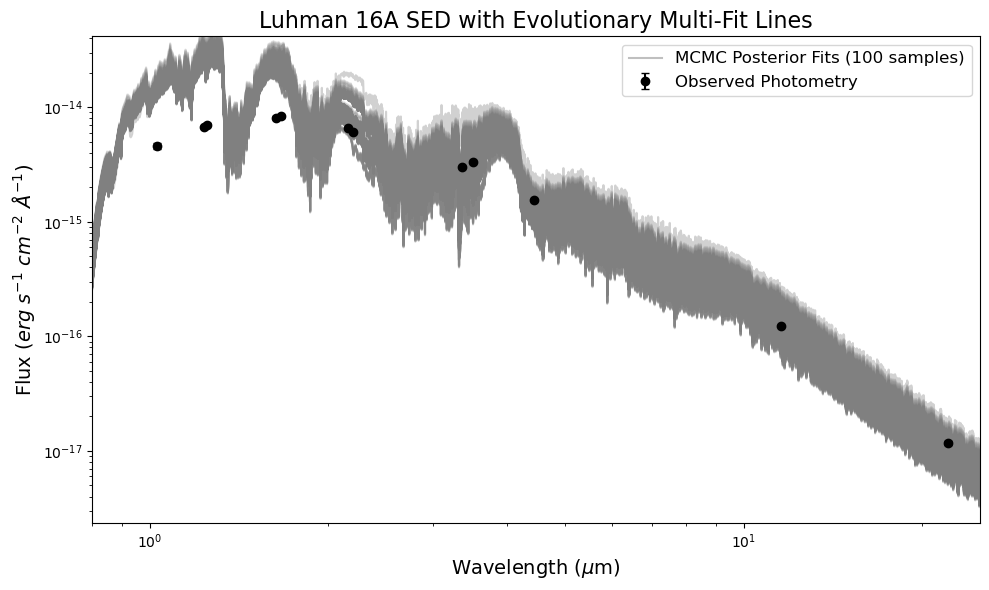


Generating MCMC posterior corner plot...


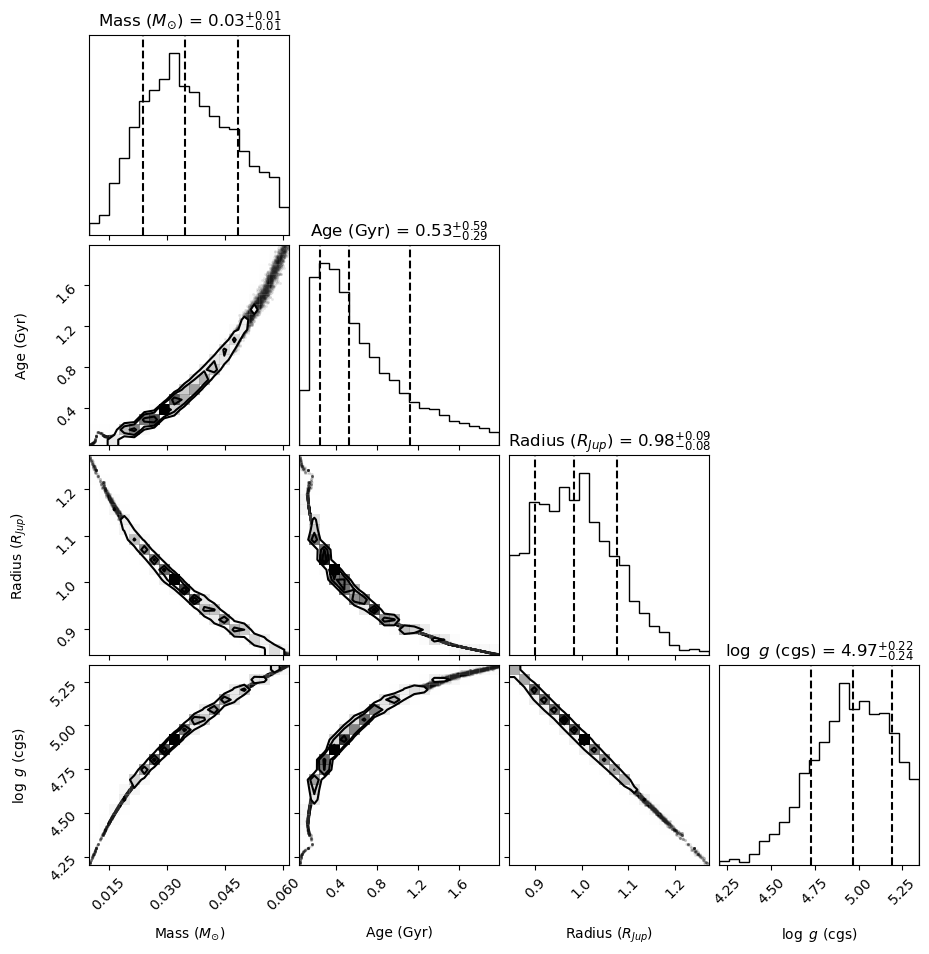

In [9]:
import importlib.resources
import astropy.units as u
import astropy.units as q
import corner
import emcee
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
from bokeh.io import output_notebook, reset_output
from sedkit import ModelGrid, sed
from scipy.interpolate import LinearNDInterpolator

# Global Conversion Factor: Solar Radii to Jupiter Radii
RSUN_TO_RJUP = (1.0 * u.R_sun).to(u.R_jup).value

# =============================================================================
# 1. INITIALIZE SED OBJECT AND TARGET PROPERTIES
# =============================================================================
s = sed.SED(name="Luhman 16A")

# Always set parallax first to anchor physical distance scaling
s.parallax = (0.50140 * u.arcsec, 0.00009 * u.arcsec, 0.00009 * u.arcsec)

# Establish empirical radius reference from literature for the MCMC Likelihood
radius_val = 1.1
radius_err = 0.1
s.radius = (radius_val * u.R_jup, radius_err * u.R_jup, radius_err * u.R_jup)

# =============================================================================
# 2. LOAD PHOTOMETRY FROM UNBLENDED CSV
# =============================================================================
phot = Table.read("Luhman_16A_unblended.csv", format="ascii.csv")

for row in phot:
    band = str(row["band"])
    if band.startswith("WFCAM"):
        band = "UKIRT/" + band

    mag = row["app_magnitude"]
    unc = row["app_magnitude_unc"]

    if np.isfinite(mag) and np.isfinite(unc):
        try:
            s.add_photometry(
                band=band,
                mag=float(mag),
                mag_unc=float(unc),
                system="Vega",
            )
        except Exception as e:
            print(f"Skipping filter {band}: {e}")

# =============================================================================
# 3. CONFIGURE FOR PHOTOMETRY-ONLY FIT (NO SPECTRA)
# =============================================================================
s.use_spectra = False
s.calibrate_spectra = False
s.calibrate_photometry = False

print(f"\nPhotometry points loaded: {len(s.photometry)}")

# =============================================================================
# 4. INITIALIZE BT-SETTL MODEL ATMOSPHERE GRID & FIT
# =============================================================================
print("\nLoading BT-Settl grid to compute robust Bolometric Luminosity...")
params = ["alpha", "logg", "teff", "meta"]
mgrid = ModelGrid("BT-Settl", params, q.AA, q.erg / q.s / q.cm**2 / q.AA)
mgrid.load("btsettl")

s.fit_modelgrid(mgrid)
s.make_sed()
best = s.best_fit

# =============================================================================
# 5. DYNAMIC PARAMETER EXTRACTION (L_bol ONLY)
# =============================================================================
results = s.results

try:
    lbol_row = results[results["param"] == "Lbol_sun"]
    lbol_val = float(lbol_row["value"][0])
    raw_lbol_err = float(lbol_row["unc"][0])
    lbol_err = max(raw_lbol_err, 0.02)
except Exception as e:
    print(f"\n[ERROR] Could not extract Lbol from results table: {e}. Falling back.")
    lbol_val = -4.54
    lbol_err = 0.02

print("\n=== ACCURATE MCMC INITIAL CONSTRAINTS EXTRACTED ===")
print(f"Empirical Log(Lbol/Lsun): {lbol_val:.3f} +/- {lbol_err:.3f}")
print(f"Empirical Radius (R_jup)  : {radius_val:.1f} +/- {radius_err:.1f}")

# =============================================================================
# 6. MCMC EVOLUTIONARY MATRIX (SONORA BOBCAT EXTENDED FOR LOG G & TEFF)
# =============================================================================
def load_sonora_grid(filepath):
    print("\nLoading Sonora Bobcat physical evolutionary models...")
    masses, ages, lbols, teffs, loggs, radii = [], [], [], [], [], []
    
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('M/Msun'):
                continue
            parts = line.split()
            if len(parts) == 1:
                continue
            if len(parts) >= 6:
                masses.append(float(parts[0]))
                ages.append(float(parts[1]))
                lbols.append(float(parts[2]))
                teffs.append(float(parts[3]))  # Column 3: Teff
                loggs.append(float(parts[4]))  # Column 4: log(g)
                radii.append(float(parts[5]))  # Column 5: Radius
                
    points = np.column_stack((masses, ages))
    
    i_lbol = LinearNDInterpolator(points, lbols)
    i_rad  = LinearNDInterpolator(points, radii) 
    i_logg = LinearNDInterpolator(points, loggs)
    i_teff = LinearNDInterpolator(points, teffs)
    
    return i_lbol, i_rad, i_logg, i_teff

i_lbol, i_rad, i_logg, i_teff = load_sonora_grid("nc+0.0_co1.0_mass")

def log_prior(theta):
    mass, age = theta
    if 0.01 < mass < 0.09 and 0.001 < age < 2:
        return 0.0
    return -np.inf

def log_probability(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf

    mass, age = theta
    try:
        model_lbol = float(i_lbol((mass, age)))
        model_radius_rsun = float(i_rad((mass, age)))
        model_radius_rjup = model_radius_rsun * RSUN_TO_RJUP
        
        if np.isnan(model_lbol) or np.isnan(model_radius_rjup):
            return -np.inf
            
        chi2_lbol = ((lbol_val - model_lbol) / lbol_err) ** 2
        chi2_rad = ((radius_val - model_radius_rjup) / radius_err) ** 2

        return lp - 0.5 * (chi2_lbol + chi2_rad)
    except Exception:
        return -np.inf

# =============================================================================
# 7. RUN EMCEE ENSEMBLE SAMPLER (3000 STEPS)
# =============================================================================
ndim, nwalkers = 2, 64

initial_mass_guess = 0.04   
initial_age_guess = 0.6     

guess_center = np.array([initial_mass_guess, initial_age_guess])
initial_state = guess_center + 1e-4 * np.random.randn(nwalkers, ndim)

initial_state[:, 0] = np.clip(initial_state[:, 0], 0.015, 0.085)
initial_state[:, 1] = np.clip(initial_state[:, 1], 0.001, 1.9)

print(f"\nRunning Markov chains ({nwalkers} walkers, 3000 steps)...")
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability)
sampler.run_mcmc(initial_state, 10000, progress=True)

# =============================================================================
# 8. POST-PROCESSING AND INFERRING LOG G
# =============================================================================
total_steps_run = sampler.iteration
discard_val = int(total_steps_run * 0.25)  

print(f"\nProcessing chains: Discarding the first {discard_val} steps as burn-in...")
flat_samples = sampler.get_chain(discard=discard_val, thin=20, flat=True)

mass_chain = flat_samples[:, 0]
age_chain = flat_samples[:, 1]

radii_rsun = i_rad(mass_chain, age_chain)
radii_rjup = radii_rsun * RSUN_TO_RJUP

logg_chain = i_logg(mass_chain, age_chain)

samples_full = np.column_stack((flat_samples, radii_rjup, logg_chain))

# =============================================================================
# 9. EXTRACT FINAL STATISTICAL POSTERIORS & UPDATE SEDKIT
# =============================================================================
def get_quantiles(chain):
    q = np.percentile(chain, [16, 50, 84])
    return q[1], q[1] - q[0], q[2] - q[1]

m_val, m_lo, m_hi = get_quantiles(mass_chain)
a_val, a_lo, a_hi = get_quantiles(age_chain)
r_val, r_lo, r_hi = get_quantiles(radii_rjup)
g_val, g_lo, g_hi = get_quantiles(logg_chain)

s.mass = (m_val * u.M_sun, m_lo * u.M_sun, m_hi * u.M_sun)
s.age = (a_val * u.Gyr, a_lo * u.Gyr, a_hi * u.Gyr)
s.radius = (r_val * u.R_jup, r_lo * u.R_jup, r_hi * u.R_jup)
s.logg = (float(g_val), float(g_lo), float(g_hi))

print("\n=== UPDATED SEDKIT RESULTS TABLE SUCCESSFULLY OVERWRITTEN ===")
s.results.pprint_all()

# =============================================================================
# 10. RENDER PUBLICATION-QUALITY SED PLOT (SPAGHETTI PLOT)
# =============================================================================
print("\nGenerating custom spaghetti plot for MCMC posteriors...")
fig, ax = plt.subplots(figsize=(10, 6))

wave_phot = s.photometry['eff'].value  
flux_phot = s.photometry['app_flux'].value
flux_err = s.photometry['app_flux_unc'].value

# A. Plot Observed Photometry Data Points
ax.errorbar(wave_phot, flux_phot, yerr=flux_err, fmt='ko', zorder=10, 
            label="Observed Photometry", markersize=6, capsize=3)

# B. Plot Multiple Posterior Sample Fit Lines (Spaghetti Plot)
dist_pc = 1.0 / s.parallax[0].to(u.arcsec).value
dist_cm = (dist_pc * u.pc).to(u.cm).value

teff_grid = np.array(mgrid.index['teff'])
logg_grid = np.array(mgrid.index['logg'])

sample_indices = np.random.randint(0, len(flat_samples), 1000)
for idx in sample_indices:
    m_samp, age_samp = flat_samples[idx]
    teff_samp = float(i_teff((m_samp, age_samp)))
    logg_samp = logg_chain[idx]
    rad_rjup_samp = radii_rjup[idx]

    grid_distance = ((teff_grid - teff_samp) / 100.0)**2 + ((logg_grid - logg_samp) / 0.5)**2
    closest_match_idx = np.argmin(grid_distance)
    
    teff_closest = float(teff_grid[closest_match_idx])
    logg_closest = float(logg_grid[closest_match_idx])

    rad_cm = (rad_rjup_samp * u.R_jup).to(u.cm).value
    scale = (rad_cm / dist_cm)**2

    try:
        spec = mgrid.get_spectrum(teff=teff_closest, logg=logg_closest, alpha=0.0, meta=0.0)
        if spec is not None:
            w_um = (spec.wave * u.AA).to(u.um).value
            f_scaled = spec.flux * scale
            ax.plot(w_um, f_scaled, color='gray', alpha=0.1, zorder=1)
    except Exception:
        continue

ax.plot([], [], color='gray', alpha=0.5, label='MCMC Posterior Fits (100 samples)')

# C. Plot the Solid MCMC Median Posterior Fit Line in Red
try:
    teff_median = float(i_teff((m_val, a_val)))
    grid_distance_med = ((teff_grid - teff_median) / 100.0)**2 + ((logg_grid - g_val) / 0.5)**2
    closest_med_idx = np.argmin(grid_distance_med)
    
    spec_med = mgrid.get_spectrum(teff=float(teff_grid[closest_med_idx]), 
                                  logg=float(logg_grid[closest_med_idx]), alpha=0.0, meta=0.0)
    if spec_med is not None:
        dist_pc = 1.0 / s.parallax[0].to(u.arcsec).value
        r_obj_cm = (s.radius[0]).to(u.cm).value
        d_obj_cm = (dist_pc * u.pc).to(u.cm).value
        median_scale = (r_obj_cm / d_obj_cm)**2
        
        w_med_um = (spec_med.wave * u.AA).to(u.um).value
        f_med_scaled = spec_med.flux * median_scale
        
        ax.plot(w_med_um, f_med_scaled, color='', linewidth=2.0, zorder=5, label="Posterior Median Fit")
        print(f"Successfully rendered aligned median fit line (Teff ~ {int(teff_median)}K).")
except Exception as e:
    print(f"Could not render median posterior line: {e}")

# Figure Customizations
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Wavelength ($\mu$m)', fontsize=14)
ax.set_ylabel('Flux ($erg\ s^{-1}\ cm^{-2}\ \AA^{-1}$)', fontsize=14)
ax.set_xlim(0.8, 25.0)  
ax.set_ylim(min(flux_phot)*0.2, max(flux_phot)*5.0)
ax.legend(loc='upper right', fontsize=12)
ax.set_title(f"{s.name} SED with Evolutionary Multi-Fit Lines", fontsize=16)

plt.tight_layout()
plt.show()

# =============================================================================
# 11. ADDED: RENDER CORNER PLOT FOR THE 1st SCRIPT
# =============================================================================
print("\nGenerating MCMC posterior corner plot...")
fig_corner = corner.corner(
    samples_full,
    labels=["Mass ($M_{\odot}$)", "Age (Gyr)", "Radius ($R_{Jup}$)", "$\log\ g$ (cgs)"],
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 12},
)
plt.show()